In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 1: Import Libraries & Load Dataset
Required libraries import kiye — data handling ke liye pandas/numpy, preprocessing ke liye StandardScaler, aur 3 models (Linear Regression, Ridge Regression, Decision Tree) ke liye sklearn. Dataset California Housing hai, target variable HousePrice hai.

In [27]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("Before scaling - MedInc range:", X['MedInc'].min(), "to", X['MedInc'].max())
print("After scaling - first column range:", X_scaled[:,0].min(), "to", X_scaled[:,0].max())

Scaling done!
Before scaling - MedInc range: 0.4999 to 15.0001
After scaling - first column range: -1.7742994673175232 to 5.858285811780286


## Step 2: Feature Scaling
StandardScaler use kiya taaki saari features ek common scale pe aa jayein. Isse model training stable hoti hai aur koi bhi feature sirf apne bade numbers ki wajah se model ko dominate nahi karta.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (16512, 8)
Testing set: (4128, 8)


In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

print("3 models ready to train:", list(models.keys()))

3 models ready to train: ['Linear Regression', 'Ridge Regression', 'Decision Tree']


## Step 3: Define Multiple Models
3 alag-alag models define kiye: Linear Regression (baseline), Ridge Regression (overfitting kam karne ke liye), aur Decision Tree (non-linear relationships pakadne ke liye).

In [31]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


## Step 4: Train & Compare All Models
Teeno models ko train kiya aur evaluate kiya RMSE aur R² Score se. Results table mein saari comparison ek jagah dikh rahi hai.

In [32]:
best_model_name = results_df['R2 Score'].idxmax()
print(f"Best performing model: {best_model_name}")
print(f"\nComparison Table:")
print(results_df)

Best performing model: Decision Tree

Comparison Table:
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732


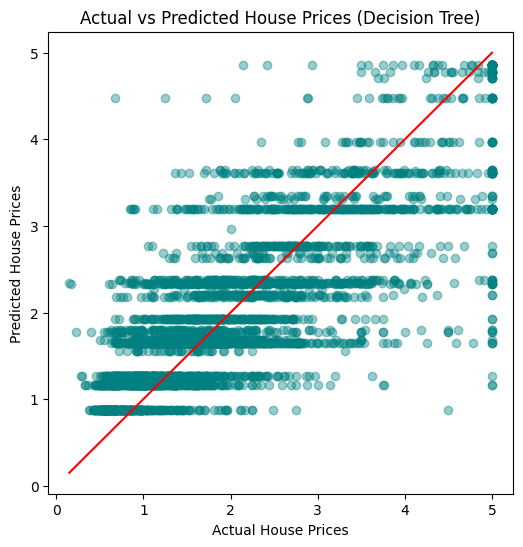

In [33]:
# Use the best model found above (dynamically selected)
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.show()

## Conclusion

- 3 models train kiye aur compare kiye: Linear Regression, Ridge Regression, aur Decision Tree
- Feature scaling (StandardScaler) use ki taaki saari features fair scale pe aayein
- Decision Tree ne sabse best perform kiya (RMSE: 0.7242, R²: 0.5997)
- Isse pata chala ki Decision Tree non-linear relationships (jaise location aur income ke complex interactions) ko Linear/Ridge Regression se behtar capture kar paaya, isliye usne lower RMSE aur higher R² diya. Linear aur Ridge dono lagbhag same perform kiye (RMSE ~0.745), jo dikhata hai ki dataset mein regularization (Ridge) se zyada fayda nahi mila kyunki overfitting zyada nahi thi.

## Skills Applied
✅ Feature Scaling (StandardScaler) ✅ Training multiple ML algorithms ✅ Model comparison using RMSE & R² ✅ Understanding overfitting prevention (Ridge, max_depth) ✅ Data-driven model selection